# HANDS ON DEEP LEARNING WITH TENSORFLOW AND KERAS

## Introduction to Artificial Neural Networks with Keras

Birds inspired us to fly, burdock plants inspired Velcro, and nature has inspired
countless more inventions. It seems only logical, then, to look at the brain’s architec
ture for inspiration on how to build an intelligent machine. This is the logic that
sparked artificial neural networks (ANNs): an ANN is a Machine Learning model
inspired by the networks of biological neurons found in our brains. However,
although planes were inspired by birds, they don’t have to flap their wings. Similarly,
ANNs have gradually become quite different from their biological cousins. Some
researchers even argue that we should drop the biological analogy altogether (e.g., by
saying “units” rather than “neurons”), lest we restrict our creativity to biologically
plausible systems.

ANNs are at the very core of Deep Learning. They are versatile, powerful, and scala
ble, making them ideal to tackle large and highly complex Machine Learning tasks
such as classifying billions of images (e.g., Google Images), powering speech recogni
tion services (e.g., Apple’s Siri), recommending the best videos to watch to hundreds
of millions of users every day (e.g., YouTube), or learning to beat the world champion
at the game of Go (DeepMind’s AlphaGo).

### From Biological to Artificial Neural Networks

Surprisingly, ANNs have been around for quite a while: they were first introduced
back in 1943 by the neurophysiologist Warren McCulloch and the mathematician
Walter Pitts. In their landmark paper2 “A Logical Calculus of Ideas Immanent in
Nervous Activity,” McCulloch and Pitts presented a simplified computational model
of how biological neurons might work together in animal brains to perform complex
computations using propositional logic. This was the first artificial neural network
architecture. Since then many other architectures have been invented, as we will see.

The early successes of ANNs led to the widespread belief that we would soon be con
versing with truly intelligent machines. When it became clear in the 1960s that this
promise would go unfulfilled (at least for quite a while), funding flew elsewhere, and
ANNs entered a long winter. In the early 1980s, new architectures were invented and
better training techniques were developed, sparking a revival of interest in connec
tionism (the study of neural networks). 

We are now witnessing yet another wave of interest in ANNs. Will this wave die out like the previous ones did? Well, here are a few good reasons to believe that this time is different and that the renewed interest in ANNs will have a much more profound impact on our lives:
- There is now a huge quantity of data available to train neural networks, and ANNs frequently outperform other ML techniques on very large and complex
problems.

- The tremendous increase in computing power since the 1990s now makes it possible to train large neural networks in a reasonable amount of time. This is in part due to Moore’s law (the number of components in integrated circuits has doubled about every 2 years over the last 50 years), but also thanks to the gaming industry, which has stimulated the production of powerful GPU cards by the millions. Moreover, cloud platforms have made this power accessible to everyone.

- The training algorithms have been improved. To be fair they are only slightly dif
ferent from the ones used in the 1990s, but these relatively small tweaks have had
a huge positive impact.

- Some theoretical limitations of ANNs have turned out to be benign in practice.
For example, many people thought that ANN training algorithms were doomed
because they were likely to get stuck in local optima, but it turns out that this is
rather rare in practice (and when it is the case, they are usually fairly close to the
global optimum).

- ANNs seem to have entered a virtuous circle of funding and progress. Amazing
products based on ANNs regularly make the headline news, which pulls more
and more attention and funding toward them, resulting in more and more pro
gress and even more amazing products


#### The Perceptron

The Perceptron is one of the simplest ANN architectures, invented in 1957 by Frank
Rosenblatt. It is based on a slightly different artificial neuron (see Figure 10-4) called
a threshold logic unit (TLU), or sometimes a linear threshold unit (LTU). The inputs
and output are numbers (instead of binary on/off values), and each input connection
is associated with a weight. The TLU computes a weighted sum of its inputs ($z = w_1*x_1+ w_2*x_2+ ⋯ +w_n*x_n= w^⊺*x$), then applies a step function to that sum and outputs the
result: $h_w(x) = step(z)$, where $z = w^T*x$.
The most common step function used in Perceptrons is the Heaviside step function. Sometimes the sign function is used instead.

A single TLU can be used for simple linear binary classification. It computes a linear combination of the inputs, and if the result exceeds a threshold, it outputs the positive class. Otherwise it outputs the negative class (just like a Logistic Regression or
linear SVM classifier). You could, for example, use a single TLU to classify iris flowers based on petal length and width (also adding an extra bias feature $x_0 = 1$, just like we did in previous chapters). Training a TLU in this case means finding the right values for $w_0, w_1, and w_2$  (the training algorithm is discussed shortly).
A Perceptron is simply composed of a single layer of TLUs, with each TLU connected to all the inputs. When all the neurons in a layer are connected to every neuron in the previous layer (i.e., its input neurons), the layer is called a fully connected layer, or a dense layer. The inputs of the Perceptron are fed to special passthrough neurons called input neurons: they output whatever input they are fed. All the input neurons form the input layer. Moreover, an extra bias feature is generally added ($x_0  = 1$): it is typically represented using a special type of neuron called a bias neuron, which out puts 1 all the time. 

Thanks to the magic of linear algebra, Equation 10-2 makes it possible to efficiently compute the outputs of a layer of artificial neurons for several instances at once.Computing the outputs of a fully connected layer:

$$h_{W,b}(X) =\phi(W^T.X+b)$$

In this equation:

• As always, $X$ represents the matrix of input features. It has one row per instance and one column per feature.

• The weight matrix W contains all the connection weights except for the ones from the bias neuron. It has one row per input neuron and one column per artificial neuron in the layer.

• The bias vector b contains all the connection weights between the bias neuron and the artificial neurons. It has one bias term per artificial neuron.

• The function $\phi$ is called the activation function: when the artificial neurons are TLUs, it is a step function (but we will discuss other activation functions shortly).

So, how is a Perceptron trained? The Perceptron training algorithm proposed by Rosenblatt was largely inspired by Hebb’s rule. In his 1949 book The Organization of Behavior (Wiley), Donald Hebb suggested that when a biological neuron triggers another neuron often, the connection between these two neurons grows stronger. Siegrid Löwel later summarized Hebb’s idea in the catchy phrase, “Cells that fire together, wire together”; that is, the connection weight between two neurons tends to increase when they fire simultaneously. This rule later became known as Hebb’s rule (or Hebbian learning). Perceptrons are trained using a variant of this rule that takes into account the error made by the network when it makes a prediction; the Perceptron learning rule reinforces connections that help reduce the error. More specifically, the Perceptron is fed one training instance at a time, and for each instance it makes its predictions. For every output neuron that produced a wrong prediction, it reinforces the connection weights from the inputs that would have contributed to the correct prediction. 

Perceptron learning rule reinforces connections that help reduce the error. More specifically, the Perceptron is fed one training instance at a time, and for each instance it makes its predictions. For every output neuron that produced a wrong prediction, it reinforces the connection weights from the inputs that would have contributed to the correct prediction.

$$w_{i, j}^{(next step)} = w_{i, j} + \eta(y_j − \hat{y}_j)$$
In this equation:

• $w_{i, j}$  is the connection weight between the $i^{th}$ input neuron and the $j^{th}$ output
neuron.

• $x_i$ is the $i^{th}$ input value of the current training instance.

• $y_j$  is the output of the $j^{th}$ output neuron for the current training instance.

• $\hat{y_j}$  is the target output of the $j^{th}$ output neuron for the current training instance.

• $\eta$ is the learning rate.

The decision boundary of each output neuron is linear, so Perceptrons are incapable of learning complex patterns (just like Logistic Regression classifiers). However, if the training instances are linearly separable, Rosenblatt demonstrated that this algorithm would converge to a solution.This is called the Perceptron convergence theorem.

In [1]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, (2, 3)]  # petal length, petal width
y = (iris.target == 0).astype(np.int32)  # Iris setosa become the positive class

per_clf = Perceptron().fit(X,y)

y_pred = per_clf.predict([[2, 0.5]])
y_pred

array([0], dtype=int32)

In [2]:
Perceptron()

Perceptron()

You may have noticed that the Perceptron learning algorithm strongly resembles Stochastic Gradient Descent. In fact, Scikit-Learn’s Perceptron class is equivalent to using an SGDClassifier with the following hyperparameters: loss="perceptron", learning_rate="constant", eta0=1 (the learning rate), and penalty=None (no regularization).

Note that contrary to Logistic Regression classifiers, Perceptrons do not output a class probability; rather, they make predictions based on a hard threshold. This is one reason to prefer Logistic Regression over Perceptrons. In their 1969 monograph Perceptrons, Marvin Minsky and Seymour Papert highlighted a number of serious weaknesses of Perceptrons—in particular, the fact that they are incapable of solving some trivial problems (e.g., the Exclusive OR (XOR) classification problem). This is true of any other linear classification model (such as Logistic Regression classifiers), but researchers had expected much more from Perceptrons, and some were so disappointed that they dropped neural networks altogether in favor of higher-level problems such as logic, problem solving, and search.

It turns out that some of the limitations of Perceptrons can be eliminated by stacking multiple Perceptrons. The resulting ANN is called a Multilayer Perceptron (MLP). An MLP can solve the XOR problem, as you can verify by computing the output of the MLP.

#### MultiLayer Back Propagation

An MLP is composed of one (passthrough) input layer, one or more layers of TLUs, called hidden layers, and one final layer of TLUs called the output layer. The layers close to the input layer are usually called the lower layers, and the ones close to the outputs are usually called the upper layers. Every layer except the output layer includes a bias neuron and is fully connected to the next layer.
When an ANN contains a deep stack of hidden layers,9 it is called a deep neural network (DNN). The field of Deep Learning studies DNNs, and more generally models containing deep stacks of computations. Even so, many people talk about Deep Learning whenever neural networks are involved (even shallow ones).

For many years researchers struggled to find a way to train MLPs, without success. But in 1986, David Rumelhart, Geoffrey Hinton, and Ronald Williams published a groundbreaking paper10 that introduced the backpropagation training algorithm, which is still used today. In short, it is Gradient Descent using an efficient technique for computing the gradients automatically:11 in just two passes through the network (one forward, one backward), the backpropagation algorithm is able to compute the gradient of the network’s error with regard to every single model parameter. In other words, it can find out how each connection weight and each bias term should be tweaked in order to reduce the error. Once it has these gradients, it just performs a regular Gradient Descent step, and the whole process is repeated until the network converges to the solution.

Automatically computing gradients is called automatic differentiation, or autodiff. There are various autodiff techniques, with different pros and cons. The one used by backpropagation is called reverse-mode autodiff. It is fast and precise, and is well suited when the function to differentiate has many variables (e.g., connection weights) and few outputs (e.g., one loss).

Let’s run through this algorithm in a bit more detail:

• It handles one mini-batch at a time (for example, containing 32 instances each), and it goes through the full training set multiple times. Each pass is called an epoch.

• Each mini-batch is passed to the network’s input layer, which sends it to the first hidden layer. The algorithm then computes the output of all the neurons in this layer (for every instance in the mini-batch). The result is passed on to the next layer, its output is computed and passed to the next layer, and so on until we get the output of the last layer, the output layer. This is the forward pass: it is exactly like making predictions, except all intermediate results are preserved since they are needed for the backward pass.

• Next, the algorithm measures the network’s output error (i.e., it uses a loss function that compares the desired output and the actual output of the network, and returns some measure of the error).

• Then it computes how much each output connection contributed to the error. This is done analytically by applying the chain rule (perhaps the most fundamental rule in calculus), which makes this step fast and precise.

• The algorithm then measures how much of these error contributions came from each connection in the layer below, again using the chain rule, working backward until the algorithm reaches the input layer. As explained earlier, this reverse pass efficiently measures the error gradient across all the connection weights in the network by propagating the error gradient backward through the network (hence the name of the algorithm).

• Finally, the algorithm performs a Gradient Descent step to tweak all the connection weights in the network, using the error gradients it just computed.

This algorithm is so important that it’s worth summarizing it again: for each training instance, the backpropagation algorithm first makes a prediction (forward pass) and measures the error, then goes through each layer in reverse to measure the error contribution from each connection (reverse pass), and finally tweaks the connection weights to reduce the error (Gradient Descent step).

It is important to initialize all the hidden layers’ connection weights randomly, or else training will fail. For example, if you initialize all
weights and biases to zero, then all neurons in a given layer will be perfectly identical, and thus backpropagation will affect them in exactly the same way, so they will remain identical. In other words, despite having hundreds of neurons per layer, your model will act as if it had only one neuron per layer: it won’t be too smart. If instead you randomly initialize the weights, you break the symmetry and allow backpropagation to train a diverse team of neurons.

In order for this algorithm to work properly, its authors made a key change to the MLP’s architecture: they replaced the step function with the logistic (sigmoid) function, $\sigma(z) = \frac{1}{1 + exp(–z)}$. This was essential because the step function contains only flat segments, so there is no gradient to work with (Gradient Descent cannot move on a flat surface), while the logistic function has a well-defined nonzero derivative everywhere, allowing Gradient Descent to make some progress at every step. In fact, the backpropagation algorithm works well with many other activation functions, not just the logistic function. Here are two other popular choices:

- The hyperbolic tangent function: $tanh(z) = 2\sigma(2z) – 1$:

Just like the logistic function, this activation function is S-shaped, continuous, and differentiable, but its output value ranges from –1 to 1 (instead of 0 to 1 in the case of the logistic function). That range tends to make each layer’s output more or less centered around 0 at the beginning of training, which often helps speed up convergence.

- The Rectified Linear Unit function: $ReLU(z) = max(0, z)$

The ReLU function is continuous but unfortunately not differentiable at z = 0 (the slope changes abruptly, which can make Gradient Descent bounce around), and its derivative is 0 for z < 0. In practice, however, it works very well and has the advantage of being fast to compute, so it has become the default. Most importantly, the fact that it does not have a maximum output value helps reduce some issues during Gradient Descent.

#### Regression MLPs

First, MLPs can be used for regression tasks. If you want to predict a single value (e.g., the price of a house, given many of its features), then you just need a single output neuron: its output is the predicted value. For multivariate regression (i.e., to predict multiple values at once), you need one output neuron per output dimension. For example, to locate the center of an object in an image, you need to predict 2D coordinates, so you need two output neurons. If you also want to place a bounding box around the object, then you need two more numbers: the width and the height of the object. So, you end up with four output neurons.

In general, when building an MLP for regression, you do not want to use any activation function for the output neurons, so they are free to output any range of values. If you want to guarantee that the output will always be positive, then you can use the ReLU activation function in the output layer. Alternatively, you can use the softplus activation function, which is a smooth variant of ReLU: $softplus(z) = log(1 + exp(z))$.

It is close to 0 when z is negative, and close to z when z is positive. Finally, if you want to guarantee that the predictions will fall within a given range of values, then you can use the logistic function or the hyperbolic tangent, and then scale the labels to the appropriate range: 0 to 1 for the logistic function and –1 to 1 for the hyperbolic tangent.

The loss function to use during training is typically the mean squared error, but if you have a lot of outliers in the training set, you may prefer to use the mean absolute error instead. Alternatively, you can use the Huber loss, which is a combination of both.

The Huber loss is quadratic when the error is smaller than a thres hold δ (typically 1) but linear when the error is larger than $\delta$. The
linear part makes it less sensitive to outliers than the mean squared error, and the quadratic part allows it to converge faster and be
more precise than the mean absolute error.

|Hyperparameter | Typical value|
|:---|:---|
|**input neurons** | One per input feature (e.g., 28 x 28 = 784 for MNIST)|
|**hidden layers**| Depends on the problem, but typically 1 to 5|
|**neurons per hidden layer** | Depends on the problem, but typically 10 to 100|
|**output neurons**| 1 per prediction dimension|
|**Hidden activation** | ReLU (or SELU)|
|**Output activation** | None, or ReLU/softplus (if positive outputs) or logistic/tanh (if bounded outputs)|
|**Loss function** | MSE or MAE/Huber (if outliers)|




#### Classification MLPs

MLPs can also be used for classification tasks. For a binary classification problem, you just need a single output neuron using the logistic activation function: the output will be a number between 0 and 1, which you can interpret as the estimated probability of the positive class. The estimated probability of the negative class is equal to one minus that number.

MLPs can also easily handle multilabel binary classification tasks. For example, you could have an email classification system that predicts whether each incoming email is ham or spam, and simultaneously predicts whether it is an urgent or nonurgent email. In this case, you would need two output neurons, both using the logistic activation function: the first would output the probability that the email is spam, and the second would output the probability that it is urgent. More generally, you would dedicate one output neuron for each positive class. Note that the output probabilities do not necessarily add up to 1. This lets the model output any combination of labels: you can have nonurgent ham, urgent ham, nonurgent spam, and perhaps even urgent spam (although that would probably be an error).

|Hyperparameter | Binary classification | Multilabel binary classification | Multiclass classification |
|:---|:---|:---|:---|
Input and hidden layers| Same as regression|Same as regression|
Output neurons| 1| 1 per label| 1 per class |
Output layer activation| Logistic | Logistic| softmax|
Loss function| Cross entropy| Cross entropy| Cross entropy|


### Implementing MLPs with Keras

Keras is a high-level Deep Learning API that allows you to easily build, train, evaluate, and execute all sorts of neural networks. Its documentation (or specification) is available at https://keras.io/. The reference implementation, also called Keras, was developed by François Chollet as part of a research project13 and was released as an open source project in March 2015. It quickly gained popularity, owing to its ease of use, flexibility, and beautiful design. To perform the heavy computations required by neural networks, this reference implementation relies on a computation backend. At
present, you can choose from three popular open source Deep Learning libraries: TensorFlow, Microsoft Cognitive Toolkit (CNTK), and Theano. Therefore, to avoid any confusion, we will refer to this reference implementation as multibackend Keras.
The most popular Deep Learning library, after Keras and TensorFlow, is Facebook’s PyTorch library. The good news is that its API is quite similar to Keras’s (in part because both APIs were inspired by Scikit-Learn and Chainer), so once you know Keras, it is not difficult to switch to PyTorch, if you ever want to. PyTorch’s popularity grew exponentially in 2018, largely thanks to its simplicity and excellent documentation, which were not TensorFlow 1.x’s main strengths. However, TensorFlow 2 is arguably just as simple as PyTorch, as it has adopted Keras as its official high-level API and its developers have greatly simplified and cleaned up the rest of the API. The documentation has also been completely reorganized, and it is much easier to find what you need now. Similarly, PyTorch’s main weaknesses (e.g., limited portability and no computation graph analysis) have been largely addressed in PyTorch 1.0. Healthy competition is beneficial to everyone.

#### Building an Image Classifier using the Sequential API

In [3]:
import tensorflow as tf
from tensorflow import keras

print(f'Tensorflow version: {tf.__version__}\nKeras version: {keras.__version__}')

Tensorflow version: 2.18.0
Keras version: 3.6.0


In [4]:
fashion_mnist = keras.datasets.fashion_mnist

In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
y_test.shape

(10000,)

In [8]:
X_valid, X_train = X_train[:5000]/255.0,X_train[5000:]/255.0
y_valid, y_train = y_train[:5000],y_train[5000:]

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [10]:
class_names[y_train[0]]

'Coat'

In [11]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model

<Sequential name=sequential, built=True>

• The first line creates a Sequential model. This is the simplest kind of Keras model for neural networks that are just composed of a single stack of layers connected sequentially. This is called the Sequential API.

• Next, we build the first layer and add it to the model. It is a Flatten layer whose role is to convert each input image into a 1D array: if it receives input data X, it computes X.reshape(-1, 1). This layer does not have any parameters; it is just there to do some simple preprocessing. Since it is the first layer in the model, you should specify the input_shape, which doesn’t include the batch size, only the shape of the instances. Alternatively, you could add a keras.layers.InputLayer as the first layer, setting input_shape=[28,28].

• Next we add a Dense hidden layer with 300 neurons. It will use the ReLU activation function. Each Dense layer manages its own weight matrix, containing all the connection weights between the neurons and their inputs. It also manages a vector of bias terms (one per neuron). When it receives some input data.

• Then we add a second Dense hidden layer with 100 neurons, also using the ReLU activation function.

• Finally, we add a Dense output layer with 10 neurons (one per class), using the softmax activation function (because the classes are exclusive)

Specifying activation="relu" is equivalent to specifying activation=keras.activations.relu. Other activation functions are available in the keras.activations package.

Instead of implementing it multiple lines, we could implement it just by writing a single line:

```
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
```

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Note that Dense layers often have a lot of parameters. For example, the first hidden
layer has 784 × 300 connection weights, plus 300 bias terms, which adds up to
235,500 parameters! This gives the model quite a lot of flexibility to fit the training
data, but it also means that the model runs the risk of overfitting, especially when you
do not have a lot of training data. 

The shape of the weight matrix depends on the number of inputs.
This is why it is recommended to specify the input_shape when
creating the first layer in a Sequential model. However, if you do
not specify the input shape, it’s OK: Keras will simply wait until it
knows the input shape before it actually builds the model. This will
happen either when you feed it actual data (e.g., during training),
or when you call its build() method. Until the model is really
built, the layers will not have any weights, and you will not be able
to do certain things (such as print the model summary or save the
model). So, if you know the input shape when creating the model,
it is best to specify it.

In [14]:
model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.6803 - loss: 1.0144 - val_accuracy: 0.8350 - val_loss: 0.5102
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8280 - loss: 0.5022 - val_accuracy: 0.8406 - val_loss: 0.4705
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8436 - loss: 0.4488 - val_accuracy: 0.8616 - val_loss: 0.4162
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8501 - loss: 0.4263 - val_accuracy: 0.8616 - val_loss: 0.4037
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8610 - loss: 0.4027 - val_accuracy: 0.8622 - val_loss: 0.3900
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8693 - loss: 0.3738 - val_accuracy: 0.8644 - val_loss: 0.3921
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8698 - loss: 0.3664 - val_accuracy: 0.8748 - val_loss: 0.3618
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8723 - loss: 0.3562 

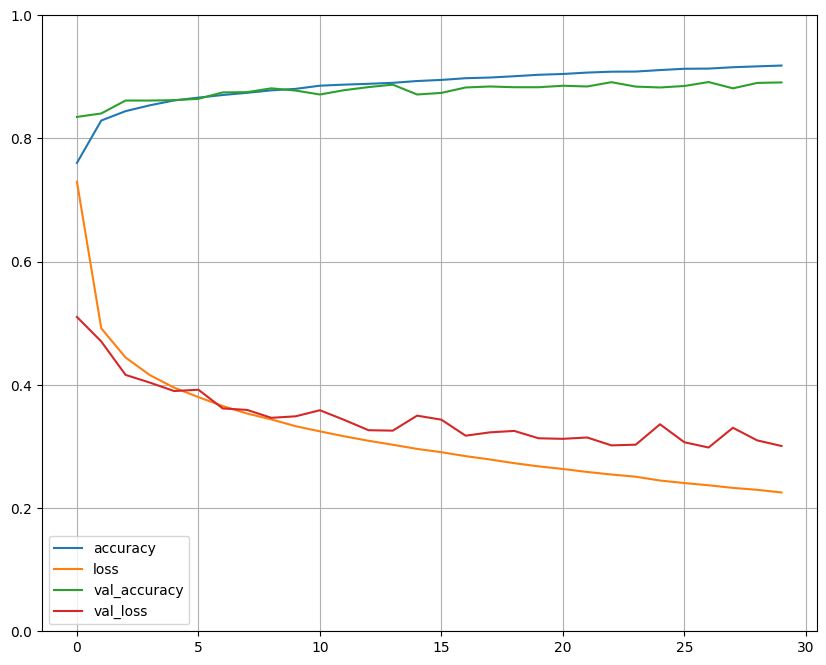

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(10,8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

You can see that both the training accuracy and the validation accuracy steadily
increase during training, while the training loss and the validation loss decrease.
Good! Moreover, the validation curves are close to the training curves, which means
that there is not too much overfitting. In this particular case, the model looks like it
performed better on the validation set than on the training set at the beginning of
training. But that’s not the case: indeed, the validation error is computed at the end of
each epoch, while the training error is computed using a running mean during each
epoch. So the training curve should be shifted by half an epoch to the left. If you do
that, you will see that the training and validation curves overlap almost perfectly at
the beginning of training

In [17]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8356 - loss: 71.9695


[75.50790405273438, 0.8330000042915344]

In [18]:
y_proba = model.predict(X_test[:5])
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 1.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 2.9747347e-11, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [19]:
y_pred = np.argmax(y_proba)
y_pred
np.array(class_names)[y_pred]

np.str_('Ankle boot')

#### Building a Regression MLP Using the Sequential API

In [22]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [23]:
model = keras.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

mse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3] # pretend these are new instances
y_pred = model.predict(X_new)

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.4787 - val_loss: 0.5640
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5081 - val_loss: 0.4812
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4656 - val_loss: 0.4465
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4188 - val_loss: 0.4279
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3933 - val_loss: 0.4202
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3921 - val_loss: 0.4184
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3931 - val_loss: 0.4091
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3848 - val_loss: 0.4122
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4008 - val_loss: 0.3978
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3961 - val_loss: 0.3994
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3797 - val_loss: 0.3926
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

In [24]:
mse_test

0.3801889717578888

In [25]:
y_pred

array([[3.4143615],
       [0.7310971],
       [1.4996428]], dtype=float32)

In [26]:
y_test[:3]

array([3.808, 0.647, 1.89 ])

#### Building Complex Models Using the Functional API

One example of a nonsequential neural network is a Wide & Deep neural network.
This neural network architecture was introduced in a 2016 paper by Heng-Tze Cheng
et al. It connects all or part of the inputs directly to the output layer. This architecture makes it possible for the neural network to learn both
deep patterns (using the deep path) and simple rules (through the short path).17 In
contrast, a regular MLP forces all the data to flow through the full stack of layers; thus, simple patterns in the data may end up being distorted by this sequence of transformations.

In [27]:
inputs_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1_ = keras.layers.Dense(30, activation="relu")(inputs_)
hidden2_ = keras.layers.Dense(30, activation='relu')(hidden1_)
concat = keras.layers.Concatenate()([inputs_, hidden2_])
output = keras.layers.Dense(1)(concat)

model = keras.Model(inputs=inputs_, outputs=output)

Let’s go through each line of this code:

• First, we need to create an Input object.18 This is a specification of the kind of
input the model will get, including its shape and dtype. A model may actually
have multiple inputs, as we will see shortly.

• Next, we create a Dense layer with 30 neurons, using the ReLU activation func
tion. As soon as it is created, notice that we call it like a function, passing it the
input. This is why this is called the Functional API. Note that we are just telling
Keras how it should connect the layers together; no actual data is being processed
yet.

• We then create a second hidden layer, and again we use it as a function. Note that
we pass it the output of the first hidden layer.

• Next, we create a Concatenate layer, and once again we immediately use it like a
function, to concatenate the input and the output of the second hidden layer. You
may prefer the keras.layers.concatenate() function, which creates a
Concatenate layer and immediately calls it with the given inputs.

• Then we create the output layer, with a single neuron and no activation function,
and we call it like a function, passing it the result of the concatenation.

• Lastly, we create a Keras Model, specifying which inputs and outputs to use.

In [28]:
model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

mse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3] # pretend these are new instances
y_pred = model.predict(X_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1800 - val_loss: 0.5400
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.4459 - val_loss: 0.4738
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4656 - val_loss: 0.4168
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4058 - val_loss: 0.4920
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4314 - val_loss: 0.3869
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3652 - val_loss: 0.3654
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7310 - val_loss: 0.3564
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3416 - val_loss: 0.3548
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3657 - val_loss: 0.3463
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3399 - val_loss: 0.3401
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3348 - val_loss: 0.3509
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

In [29]:
mse_test

0.35696595907211304

In [30]:
y_pred

array([[3.3728807 ],
       [0.52717227],
       [1.4375343 ]], dtype=float32)

In [31]:
y_test[:3]

array([3.808, 0.647, 1.89 ])

In [32]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)

model = keras.Model(inputs=[input_A, input_B], outputs=[output])

model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

history = model.fit((X_train_A, X_train_B), y_train, epochs=20,validation_data=((X_valid_A, X_valid_B), y_valid))

mse_test = model.evaluate((X_test_A, X_test_B), y_test)

y_pred = model.predict((X_new_A, X_new_B))

Epoch 1/20


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['wide_input', 'deep_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.8558 - val_loss: 0.7861
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.6988 - val_loss: 0.6798
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6276 - val_loss: 0.6360
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5975 - val_loss: 0.6031
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5426 - val_loss: 0.5740
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5220 - val_loss: 0.5492
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5207 - val_loss: 0.5286
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5070 - val_loss: 0.5120
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4870 - val_loss: 0.4953
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4726 - val_loss: 0.4830
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4643 - val_loss: 0.4716
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.

In [33]:
mse_test

0.43977177143096924

In [34]:
y_pred

array([[3.438377 ],
       [0.6391624],
       [1.70163  ]], dtype=float32)

There are many use cases in which you may want to have multiple outputs:

• The task may demand it. For instance, you may want to locate and classify the
main object in a picture. This is both a regression task (finding the coordinates of
the object’s center, as well as its width and height) and a classification task.

• Similarly, you may have multiple independent tasks based on the same data. Sure,
you could train one neural network per task, but in many cases you will get better
results on all tasks by training a single neural network with one output per task.
This is because the neural network can learn features in the data that are useful
across tasks. For example, you could perform multitask classification on pictures
of faces, using one output to classify the person’s facial expression (smiling, sur
prised, etc.) and another output to identify whether they are wearing glasses or
not.

• Another use case is as a regularization technique (i.e., a training constraint whose
objective is to reduce overfitting and thus improve the model’s ability to general
ize). For example, you may want to add some auxiliary outputs in a neural net
work architecture (see Figure 10-16) to ensure that the underlying part of the
network learns something useful on its own, without relying on the rest of the
network

In [35]:
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])

Each output will need its own loss function. Therefore, when we compile the model,
we should pass a list of losses (if we pass a single loss, Keras will assume that the
same loss must be used for all outputs). By default, Keras will compute all these losses
and simply add them up to get the final loss used for training. We care much more
about the main output than about the auxiliary output (as it is just used for regulari
zation), so we want to give the main output’s loss a much greater weight. Fortunately,
it is possible to set all the loss weights when compiling the model:

In [36]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer="sgd")

In [37]:
history = model.fit([X_train_A, X_train_B], [y_train, y_train], epochs=20,
validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]))

total_loss, main_loss, aux_loss = model.evaluate([X_test_A, X_test_B], [y_test, y_test])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - aux_output_loss: 0.2215 - loss: 1.1703 - main_output_loss: 0.9487 - val_aux_output_loss: 0.1065 - val_loss: 0.5258 - val_main_output_loss: 0.4191
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - aux_output_loss: 0.0960 - loss: 0.4734 - main_output_loss: 0.3774 - val_aux_output_loss: 0.0911 - val_loss: 0.5247 - val_main_output_loss: 0.4334
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - aux_output_loss: 0.0827 - loss: 0.4688 - main_output_loss: 0.3861 - val_aux_output_loss: 0.0809 - val_loss: 0.4747 - val_main_output_loss: 0.3936
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - aux_output_loss: 0.0761 - loss: 0.4587 - main_output_loss: 0.3826 - val_aux_output_loss: 0.0730 - val_loss: 0.4525 - val_main_output_loss: 0.3794
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - aux_output_loss: 0.0680 - loss: 0.4205 - main_output_loss: 0.3525 - val_aux_output_loss: 0.0692 - val_loss: 0.4473 - val_main_output_loss: 0.

In [38]:
total_loss, main_loss, aux_loss

(0.374510794878006, 0.321381539106369, 0.0519368015229702)

#### Using the Subclassing API to Build Dynamic Models

Both the Sequential API and the Functional API are declarative: you start by declar
ing which layers you want to use and how they should be connected, and only then
can you start feeding the model some data for training or inference. This has many
advantages: the model can easily be saved, cloned, and shared; its structure can be
displayed and analyzed; the framework can infer shapes and check types, so errors
can be caught early (i.e., before any data ever goes through the model). It’s also fairly
easy to debug, since the whole model is a static graph of layers. But the flip side is just
that: it’s static. Some models involve loops, varying shapes, conditional branching,
and other dynamic behaviors. For such cases, or simply if you prefer a more impera
tive programming style, the Subclassing API is for you.
Simply subclass the Model class, create the layers you need in the constructor, and use
them to perform the computations you want in the call() method. For example, cre
ating an instance of the following WideAndDeepModel class gives us an equivalent
model to the one we just built with the Functional API. 

In [39]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output=keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel()

#### Using TensorBoard for Visualization

TensorBoard is a great interactive visualization tool that you can use to view the
learning curves during training, compare learning curves between multiple runs, vis
ualize the computation graph, analyze training statistics, view images generated by
your model, visualize complex multidimensional data projected down to 3D and
automatically clustered for you, and more! This tool is installed automatically when
you install TensorFlow, so you already have it.
To use it, you must modify your program so that it outputs the data you want to visu
alize to special binary log files called event files. Each binary data record is called a
summary. The TensorBoard server will monitor the log directory, and it will automat
ically pick up the changes and update the visualizations: this allows you to visualize
live data (with a short delay), such as the learning curves during training. In general,
you want to point the TensorBoard server to a root log directory and configure your
program so that it writes to a different subdirectory every time it runs. This way, the
same TensorBoard server instance will allow you to visualize and compare data from
multiple runs of your program, without getting everything mixed up.

### Fine-tuning Neural Network Hyperparameters

The flexibility of neural networks is also one of their main drawbacks: there are many
hyperparameters to tweak. Not only can you use any imaginable network architec
ture, but even in a simple MLP you can change the number of layers, the number of
neurons per layer, the type of activation function to use in each layer, the weight initi
alization logic, and much more. How do you know what combination of hyperpara
meters is the best for your task?

One option is to simply try many combinations of hyperparameters and see which
one works best on the validation set (or use K-fold cross-validation). For example, we
can use GridSearchCV or RandomizedSearchCV to explore the hyperparameter space. To do this, we need to wrap our Keras models in objects that
mimic regular Scikit-Learn regressors. 

In [40]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=learning_rate),loss="mse",metrics=["accuracy"])
    return model


In [41]:
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(build_model)

In [42]:
keras_reg.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0022 - loss: 1.7002 - val_accuracy: 0.0028 - val_loss: 0.6792
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0030 - loss: 0.6299 - val_accuracy: 0.0028 - val_loss: 0.5941
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0038 - loss: 0.5433 - val_accuracy: 0.0028 - val_loss: 0.5471
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0031 - loss: 0.5301 - val_accuracy: 0.0028 - val_loss: 0.5158
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0034 - loss: 0.4894 - val_accuracy: 0.0028 - val_loss: 0.4968
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0030 - loss: 0.4643 - val_accuracy: 0.0028 - val_loss: 0.4798
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0028 - loss: 0.4573 - val_accuracy: 0.0028 - val_loss: 0.4733
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0022 - loss: 0.4314 - val_accu

In [49]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
"n_hidden": [0, 1, 2, 3],
"n_neurons": np.arange(1, 100),
"learning_rate": reciprocal(3e-4, 3e-2),
}
rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3)


In [57]:
rnd_search_cv.estimator

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

KerasRegressor(
	model=<function build_model at 0x000001C89AF15FC0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
)

In [ ]:
regressor = rnd_search_cv.estimator

In [48]:
regressor.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[keras.callbacks.EarlyStopping(patience=10)])

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0016 - loss: 2.2431 - val_accuracy: 0.0028 - val_loss: 0.7119
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0028 - loss: 0.6563 - val_accuracy: 0.0028 - val_loss: 0.6394
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0018 - loss: 0.6359 - val_accuracy: 0.0028 - val_loss: 0.5595
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0024 - loss: 0.5372 - val_accuracy: 0.0028 - val_loss: 0.5342
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0037 - loss: 0.5128 - val_accuracy: 0.0028 - val_loss: 0.4989
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0028 - loss: 0.4796 - val_accuracy: 0.0028 - val_loss: 0.4864
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0031 - loss: 0.4611 - val_accuracy: 0.0028 - val_loss: 0.4706
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0021 - loss: 0.4940 - val_accu

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KerasRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

KerasRegressor(
	model=<function build_model at 0x000001C89AF15FC0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
)

Fortunately, there are many techniques to explore a search space much more efficiently than randomly. Their core idea is simple: when a region of the space turns out to be good, it should be explored more. Such techniques take care of the “zooming” process for you and lead to much better solutions in much less time. Here are some Python libraries you can use to optimize hyperparameters:

- **Hyperopt:** A popular library for optimizing over all sorts of complex search spaces (including real values, such as the learning rate, and discrete values, such as the number of layers).

- **Hyperas, kopt, or Talos:** Useful libraries for optimizing hyperparameters for Keras models (the first two are based on Hyperopt).

- **Keras Tuner:** An easy-to-use hyperparameter optimization library by Google for Keras models, with a hosted service for visualization and analysis.

- **Scikit-Optimize (skopt):** A general-purpose optimization library. The BayesSearchCV class performs Bayesian optimization using an interface similar to GridSearchCV.

- **Spearmint:** A Bayesian optimization library

- **Hyperband:** A fast hyperparameter tuning library based on the recent Hyperband paper22 by Lisha Li et al.

- **Sklearn-Deap:** A hyperparameter optimization library based on evolutionary algorithms, with a GridSearchCV-like interface

Hyperparameter tuning is still an active area of research, and evolutionary algorithms
are making a comeback. For example, check out DeepMind’s excellent 2017 paper,
23
where the authors jointly optimize a population of models and their hyperparameters. Google has also used an evolutionary approach, not just to search for hyperparameters but also to look for the best neural network architecture for the problem; their AutoML suite is already available as a cloud service. Perhaps the days of building neural networks manually will soon be over? Check out Google’s post on this topic. In fact, evolutionary algorithms have been used successfully to train individual neural networks, replacing the ubiquitous Gradient Descent! For an example, see the 2017
post by Uber where the authors introduce their Deep Neuroevolution technique. But despite all this exciting progress and all these tools and services, it still helps to have an idea of what values are reasonable for each hyperparameter so that you can build a quick prototype and restrict the search space. The following sections provide guidelines for choosing the number of hidden layers and neurons in an MLP and for selecting good values for some of the main hyperparameters.

#### Number of hidden layers

For many problems, you can begin with a single hidden layer and get reasonable results. An MLP with just one hidden layer can theoretically model even the most complex functions, provided it has enough neurons. But for complex problems, deep networks have a much higher parameter efficiency than shallow ones: they can model complex functions using exponentially fewer neurons than shallow nets, allowing them to reach much better performance with the same amount of training data. To understand why, suppose you are asked to draw a forest using some drawing software, but you are forbidden to copy and paste anything. It would take an enormous amount of time: you would have to draw each tree individually, branch by branch, leaf by leaf. If you could instead draw one leaf, copy and paste it to draw a branch, then copy and paste that branch to create a tree, and finally copy and paste this tree to make a forest, you would be finished in no time. Real-world data is often structured in such a hierarchical way, and deep neural networks automatically take advantage of this fact: lower hidden layers model low-level structures (e.g., line segments of various shapes and orientations), intermediate hidden layers combine these low-level structures to model intermediate-level structures (e.g., squares, circles), and the highest hidden layers and the output layer combine these intermediate structures to model high-level structures (e.g., faces).

Not only does this hierarchical architecture help DNNs converge faster to a good solution, but it also improves their ability to generalize to new datasets. For example, if you have already trained a model to recognize faces in pictures and you now want to train a new neural network to recognize hairstyles, you can kickstart the training by reusing the lower layers of the first network. Instead of randomly initializing the weights and biases of the first few layers of the new neural network, you can initialize them to the values of the weights and biases of the lower layers of the first network.

This way the network will not have to learn from scratch all the low-level structures that occur in most pictures; it will only have to learn the higher-level structures (e.g., hairstyles). This is called *transfer learning*

In summary, for many problems you can start with just one or two hidden layers and the neural network will work just fine. For instance, you can easily reach above 97% accuracy on the MNIST dataset using just one hidden layer with a few hundred neurons, and above 98% accuracy using two hidden layers with the same total number of neurons, in roughly the same amount of training time. For more complex problems, you can ramp up the number of hidden layers until you start overfitting the training set. Very complex tasks, such as large image classification or speech recognition, typically require networks with dozens of layers (or even hundreds, but not fully connected ones).

#### Number of neurons per hidden layer

The number of neurons in the input and output layers is determined by the type of input and output your task requires. For example, the MNIST task requires 28 × 28 = 784 input neurons and 10 output neurons.

As for the hidden layers, it used to be common to size them to form a pyramid, with fewer and fewer neurons at each layer—the rationale being that many low-level features can coalesce into far fewer high-level features. A typical neural network for MNIST might have 3 hidden layers, the first with 300 neurons, the second with 200, and the third with 100. However, this practice has been largely abandoned because it seems that using the same number of neurons in all hidden layers performs just as well in most cases, or even better; plus, there is only one hyperparameter to tune, instead of one per layer. That said, depending on the dataset, it can sometimes help to make the first hidden layer bigger than the others.

Just like the number of layers, you can try increasing the number of neurons gradually until the network starts overfitting. But in practice, it’s often simpler and more efficient to pick a model with more layers and neurons than you actually need, then use early stopping and other regularization techniques to prevent it from overfitting.

Vincent Vanhoucke, a scientist at Google, has dubbed this the “stretch pants” approach: instead of wasting time looking for pants that perfectly match your size, just use large stretch pants that will shrink down to the right size. With this approach, you avoid bottleneck layers that could ruin your model. On the flip side, if a layer has too few neurons, it will not have enough representational power to preserve all the useful information from the inputs (e.g., a layer with two neurons can only output 2D data, so if it processes 3D data, some information will be lost). No matter how big and
powerful the rest of the network is, that information will never be recovered.

#### Learning Rate, Batch Size and Other Hyperparameters

- **Learning rate:** One way to find a good learning rate is to train the model for a few hundred iterations, starting with a very low learning rate (e.g., $10^{-5}$) and gradually increasing it up to a very large value (e.g., 10). This is done by multiplying the learning rate by a constant factor at each iteration (e.g., by $exp(log(10^{-6} )/500)$ to go from $10^{-5}$ to 10 in 500 iterations). If you plot the loss as a function of the learning rate (using a log scale for the learning rate), you should see it dropping at first. But after a while, the learning rate will be too large, so the loss will shoot back up: the optimal learning rate will be a bit lower than the point at which the loss starts to climb (typically about 10 times lower than the turning point). You can then reinitialize your model and train it normally using this good learning rate.

- **Optimizer**

- **Batch size:** The batch size can have a significant impact on your model’s performance and training time. The main benefit of using large batch sizes is that hardware accelerators like GPUs can process them efficiently, so the training algorithm will see more instances per second. Therefore, many researchers and practitioners recommend using the largest batch size that can fit in GPU RAM. There’s a catch, though: in practice, large batch sizes often lead to training instabilities, especially at the beginning of training, and the resulting model may not generalize as well as a model trained with a small batch size. In April 2018, Yann LeCun even tweeted “Friends don’t let friends use mini-batches larger than 32,” citing a 2018 paper24 by Dominic Masters and Carlo Luschi which concluded that using small batches (from 2 to 32) was preferable because small batches led to better models in less training time. Other papers point in the opposite direction, however; in 2017, papers by Elad Hoffer et al.25 and Priya Goyal et al.26 showed that it was possible to use very large batch sizes (up to 8,192) using various techniques such as warming up the learning rate (i.e., starting training with a small learning rate, then ramping it up). This led to a very short training time, without any generalization gap. So, one strategy is to try to use a large batch size, using learning rate warmup, and if training is unstable or the final performance is disappointing, then try using a small batch size instead.

- **Activation function:** in general, the ReLU activation function will be a good default for all hidden layers. For the output layer, it really depends on your task.

- **Number of iterations:** In most cases, the number of training iterations does not actually need to be tweaked: just use early stopping instead.

For more best practices regarding tuning neural network hyperparameters, check out the excellent 2018 paper27 by Leslie Smith.

## Training Deep Neural Networks

What if you need to tackle a complex problem, such as detecting hundreds of types of objects in high-resolution images? You may need to train a much deeper DNN, perhaps with 10 layers or many more, each containing hundreds of neurons, linked by hundreds of thousands of connections. Training a deep DNN isn’t a walk in the park. Here are some of the problems you could run into:

• You may be faced with the tricky vanishing gradients problem or the related exploding gradients problem. This is when the gradients grow smaller and
smaller, or larger and larger, when flowing backward through the DNN during training. Both of these problems make lower layers very hard to train.

• You might not have enough training data for such a large network, or it might be too costly to label.

• Training may be extremely slow.

• A model with millions of parameters would severely risk overfitting the training set, especially if there are not enough training instances or if they are too noisy.

### The Vanishing/Exploding Gradient Problems 

Unfortunately, gradients often get smaller and smaller as the algorithm progresses down to the lower layers. As a result, the Gradient Descent update leaves the lower layers’ connection weights virtually unchanged, and training never converges to a good solution. We call this the vanishing gradients problem. In some cases, the opposite can happen: the gradients can grow bigger and bigger until layers get insanely large weight updates and the algorithm diverges. This is the exploding gradients problem, which surfaces in recurrent neural networks. More generally, deep neural networks suffer from unstable gradients; different layers may learn at widely different speeds.

This unfortunate behavior was empirically observed long ago, and it was one of the reasons deep neural networks were mostly abandoned in the early 2000s. It wasn’t clear what caused the gradients to be so unstable when training a DNN, but some light was shed in a 2010 paper by Xavier Glorot and Yoshua Bengio.1 The authors found a few suspects, including the combination of the popular logistic sigmoid activation function and the weight initialization technique that was most popular at the time (i.e., a normal distribution with a mean of 0 and a standard deviation of 1). In short, they showed that with this activation function and this initialization scheme, the variance of the outputs of each layer is much greater than the variance of its inputs. Going forward in the network, the variance keeps increasing after each layer until the activation function saturates at the top layers. This saturation is actually made worse by the fact that the logistic function has a mean of 0.5, not 0 (the hyperbolic tangent function has a mean of 0 and behaves slightly better than the logistic function in deep networks).

Looking at the logistic activation function, you can see that when inputs become large (negative or positive), the function saturates at 0 or 1, with a
derivative extremely close to 0. Thus, when backpropagation kicks in it has virtually no gradient to propagate back through the network; and what little gradient exists keeps getting diluted as backpropagation progresses down through the top layers, so there is really nothing left for the lower layers.



#### Glorot and He Initialization

In their paper, Glorot and Bengio propose a way to significantly alleviate the unstable gradients problem. They point out that we need the signal to flow properly in both directions: in the forward direction when making predictions, and in the reverse direction when backpropagating gradients. We don’t want the signal to die out, nor do we want it to explode and saturate. For the signal to flow properly, the authors argue that we need the variance of the outputs of each layer to be equal to the variance of its inputs, and we need the gradients to have equal variance before and after
flowing through a layer in the reverse direction (please check out the paper if you are interested in the mathematical details). It is actually not possible to guarantee both unless the layer has an equal number of inputs and neurons (these numbers are called the fan-in and fan-out of the layer), but Glorot and Bengio proposed a good compromise that has proven to work very well in practice: the connection weights of each layer must be initialized randomly, where $$fan_{avg} = (fan_{in}+ fan_{out})/2.$$ This initialization strategy is called Xavier initialization or Glorot initialization, after the paper’s first author.

Glorot initialization (when using the logistic activation function)

Normal distribution with mean 0 and variance $\sigma^2 = \frac{1}{fan_{avg}}$
Or a uniform distribution between $\left[ -r, r \right]$, with $r = sqrt(frac{3}{fan_{avg}})$

If you replace fanavg with fanin in Equation 11-1, you get an initialization strategy that Yann LeCun proposed in the 1990s. He called it LeCun initialization. Genevieve Orr and Klaus-Robert Müller even recommended it in their 1998 book Neural Networks:  Tricks of the Trade (Springer). LeCun initialization is equivalent to Glorot initialization when fanin = fanout. It took over a decade for researchers to realize how important this trick is. Using Glorot initialization can speed up training considerably, and it is one of the tricks that led to the success of Deep Learning.
Some papers have provided similar strategies for different activation functions.

These strategies differ only by the scale of the variance and whether they use $fan_{avg}$ or $fan_{int}$, $r=\sqrt{3\sigma^2}$.

The initialization strategy for the ReLU activation function (and its variants, including the ELU activation described shortly) is sometimes called He initialization, after the paper’s first author. The SELU activation function will be explained later in this chapter. It should be used with LeCun initialization (preferably with a normal distribution, as we will see).

|Initialization | Activation functions | $\sigma^2$ (Normal)|
|---|---|---|
|Glorot| None, tanh, logistic, softmax | $1 / fan_{avg}$|
|He |ReLU and variants |$2/fan_{in}$|
|LeCun| SELU| $1 / fan_{in}$|

By default, Keras uses Glorot initialization with a uniform distribution. When creating a layer, you can change this to He initialization by setting kernel_initializer="he_uniform" or kernel_initializer="he_normal" like this:
```
keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal")
```
If you want He initialization with a uniform distribution but based on $fan_{avg}$ rather than $fan_{in}$, you can use the VarianceScaling initializer like this:

```
he_avg_init = keras.initializers.VarianceScaling(scale=2., mode='fan_avg',  distribution='uniform')
keras.layers.Dense(10, activation="sigmoid", kernel_initializer=he_avg_init)
```

#### Nonsaturating Activation Functions

One of the insights in the 2010 paper by Glorot and Bengio was that the problems with unstable gradients were in part due to a poor choice of activation function. Until then most people had assumed that if Mother Nature had chosen to use roughly sigmoid activation functions in biological neurons, they must be an excellent choice. But it turns out that other activation functions behave much better in deep neural networks—in particular, the ReLU activation function, mostly because it does not saturate for positive values (and because it is fast to compute).

To solve this problem, you may want to use a variant of the ReLU function, such as
the leaky ReLU. This function is defined as $LeakyReLU_{\alpha} (z) = max(\alpha z, z)$. The hyperparameter α defines how much the function “leaks”: it is the slope of the function for z < 0 and is typically set to 0.01. This small slope ensures that leaky ReLUs never die; they can go into a long coma, but they have a chance to eventually wake up. A 2015 paper compared several variants of the ReLU activation function, and one of its conclusions was that the leaky variants always outperformed the strict ReLU activation function. In fact, setting $\alpha = 0.2$ (a huge leak) seemed to result
in better performance than $\alpha = 0.01$ (a small leak). The paper also evaluated the randomized leaky ReLU (RReLU), where α is picked randomly in a given range during training and is fixed to an average value during testing. RReLU also performed fairly well and seemed to act as a regularizer (reducing the risk of overfitting the training set). Finally, the paper evaluated the parametric leaky ReLU (PReLU), where $\alpha$ is authorized to be learned during training (instead of being a hyperparameter, it becomes a parameter that can be modified by backpropagation like any other parameter). PReLU was reported to strongly outperform ReLU on large image datasets, but on smaller datasets it runs the risk of overfitting the training set.

Last but not least, a 2015 paper by Djork-Arné Clevert et al.proposed a new activation function called the exponential linear unit (ELU) that outperformed all the ReLU variants in the authors’ experiments: training time was reduced, and the neural network performed better on the test set.

$$ELU_\alpha(z) =  \alpha \exp(z − 1) \text{ if } z < 0, z \text{ if } z ≥ 0.$$

The ELU activation function looks a lot like the ReLU function, with a few major differences:

• It takes on negative values when $z < 0$, which allows the unit to have an average output closer to 0 and helps alleviate the vanishing gradients problem. The hyperparameter $\alpha$ defines the value that the ELU function approaches when z is a large negative number. It is usually set to 1, but you can tweak it like any other hyperparameter.

• It has a nonzero gradient for z < 0, which avoids the dead neurons problem.

• If α is equal to 1 then the function is smooth everywhere, including around z = 0, which helps speed up Gradient Descent since it does not bounce as much to the left and right of z = 0.

The main drawback of the ELU activation function is that it is slower to compute than the ReLU function and its variants (due to the use of the exponential function). Its faster convergence rate during training compensates for that slow computation, but still, at test time an ELU network will be slower than a ReLU network. 

Then, a 2017 paper by Günter Klambauer et al. introduced the Scaled ELU (SELU) activation function: as its name suggests, it is a scaled variant of the ELU activation function. The authors showed that if you build a neural network composed exclusively of a stack of dense layers, and if all hidden layers use the SELU activation function, then the network will self-normalize: the output of each layer will tend to preserve a mean of 0 and standard deviation of 1 during training, which solves the vanishing/exploding gradients problem. As a result, the SELU activation function often significantly outperforms other activation functions for such neural nets (especially deep ones).

There are, however, a few conditions for self-normalization to happen (see the paper for the mathematical justification):

• The input features must be standardized (mean 0 and standard deviation 1).

• Every hidden layer’s weights must be initialized with LeCun normal initialization. In Keras, this means setting kernel_initializer="lecun_normal".

• The network’s architecture must be sequential. Unfortunately, if you try to use SELU in nonsequential architectures, such as recurrent networks or networks with skip connections (i.e., connections that skip layers, such as in Wide & Deep nets), self-normalization will not be guaranteed, so SELU will not necessarily outperform other activation functions.

• The paper only guarantees self-normalization if all layers are dense, but some researchers have noted that the SELU activation function can improve performance in convolutional neural nets as well 

So, which activation function should you use for the hidden layers of your deep neural networks? Although your mileage will vary, in general SELU > ELU > leaky ReLU (and its variants) > ReLU > tanh > logistic. If the network’s architecture prevents it from selfnormalizing, then ELU may perform better than SELU (since SELU is not smooth at z = 0). If you care a lot about runtime latency, then you may prefer leaky ReLU. If you don’t want to tweak yet another hyperparameter, you may use the default α values used by Keras (e.g., 0.3 for leaky ReLU). If you have spare time and computing power, you can use cross-validation to evaluate other activation functions, such as RReLU if your network is overfitting or PReLU if you have a huge training set. That said, because ReLU is the most used activation function (by far), many libraries and hardware accelerators provide ReLU-specific optimizations; therefore, if speed is your priority, ReLU might still be the best choice.

#### Batch Normalization

Although using He initialization along with ELU (or any variant of ReLU) can significantly reduce the danger of the vanishing/exploding gradients problems at the beginning of training, it doesn’t guarantee that they won’t come back during training.
In a 2015 paper,
8
 Sergey Ioffe and Christian Szegedy proposed a technique called Batch Normalization (BN) that addresses these problems. The technique consists of
adding an operation in the model just before or after the activation function of each hidden layer. This operation simply zero-centers and normalizes each input, then scales and shifts the result using two new parameter vectors per layer: one for scaling, the other for shifting. In other words, the operation lets the model learn the optimal scale and mean of each of the layer’s inputs. In many cases, if you add a BN layer as the very first layer of your neural network, you do not need to standardize your training set (e.g., using a StandardScaler); the BN layer will do it for you (well, approxi‐
mately, since it only looks at one batch at a time, and it can also rescale and shift each input feature).

In order to zero-center and normalize the inputs, the algorithm needs to estimate each input’s mean and standard deviation. It does so by evaluating the mean and standard deviation of the input over the current mini-batch (hence the name “Batch Normalization”). 

1. $\mu_B = \frac{1}{m_B}\sum_{i=1}^{m_B}X^{(i)}$
2. $\sigma^2 = \frac{1}{m_B}\sum_{i=1}^{m_B}(X^{(i)}-\mu_B)^2$
3. $\hat{X}^{(i)} = \frac{X^{(i)}-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}$
4. $\hat{z^{i}} = \gamma \times X^{(i)} + \beta$

In this algorithm:

• $\mu_B$  is the vector of input means, evaluated over the whole mini-batch B (it contains one mean per input).

• $\sigma_B$ is the vector of input standard deviations, also evaluated over the whole minibatch (it contains one standard deviation per input).

• $m_B$ is the number of instances in the mini-batch.

• $X^{(i)}$  is the vector of zero-centered and normalized inputs for instance i.

• $\gamma$ is the output scale parameter vector for the layer (it contains one scale parameter per input).

• ⊗ represents element-wise multiplication (each input is multiplied by its corresponding output scale parameter).

• $\beta$ is the output shift (offset) parameter vector for the layer (it contains one offset parameter per input). Each input is offset by its corresponding shift parameter.

• $\epsilon$ is a tiny number that avoids division by zero (typically $10^{–5}$). This is called a smoothing term.

• $z^{(i)}$ is the output of the BN operation. It is a rescaled and shifted version of the inputs


In [58]:
model = keras.models.Sequential([
 keras.layers.Flatten(input_shape=[28, 28]),
 keras.layers.BatchNormalization(),
 keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
 keras.layers.BatchNormalization(),
 keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
 keras.layers.BatchNormalization(),
 keras.layers.Dense(10, activation="softmax")
])

model.summary()

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

As you can see, each BN layer adds four parameters per input: γ, β, μ, and σ (for example, the first BN layer adds 3,136 parameters, which is 4 × 784). The last two parameters, μ and σ, are the moving averages; they are not affected by backpropagation, so Keras calls them “non-trainable” (if you count the total number of BN parameters, 3,136 + 1,200 + 400, and divide by 2, you get 2,368, which is the total number of non-trainable parameters in this model).

In [61]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

The authors of the BN paper argued in favor of adding the BN layers before the activation functions, rather than after (as we just did). There is some debate about this, as which is preferable seems to depend on the task—you can experiment with this too to see which option works best on your dataset. To add the BN layers before the activation functions, you must remove the activation function from the hidden layers and add them as separate layers after the BN layers. Moreover, since a Batch Normalization layer includes one offset parameter per input

In [62]:
model = keras.models.Sequential([
 keras.layers.Flatten(input_shape=[28, 28]),
 keras.layers.BatchNormalization(),
 keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
 keras.layers.BatchNormalization(),
 keras.layers.Activation("elu"),
 keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
 keras.layers.BatchNormalization(),
 keras.layers.Activation("elu"),
 keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 300)                 │         235,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 100)                 │          30,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 270,946 (1.03 MB)

 Trainable params: 268,578 (1.02 MB)

 Non-trainable params: 2,368 (9.25 KB)

#### Gradient-Clipping

Another popular technique to mitigate the exploding gradients problem is to clip the gradients during backpropagation so that they never exceed some threshold. This is called Gradient Clipping. This technique is most often used in recurrent neural networks, as Batch Normalization is tricky to use in RNNs.


In [63]:
optimizer = keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="mse", optimizer=optimizer)

In [64]:
model

<Sequential name=sequential_5, built=True>